# Cell type classification - parameters based on the monkey analysis

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

## Parameters

In [4]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

MONKEY_LIST = ['L','N','F'] 
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']

In [5]:
WIDTH_INTERVALS = [[0,7],[8,12],[13,90]]  # in 30 kHz sampling rates units, division between narrow, medium and wide
FIRST_PEAK_HEIGHT_TH = 1.2  # the height of the first zsc peak to divide biphasic and triphasic cells in narrow and medium

In [6]:
COLORS_CLASSES = {
         'Down_Narrow_Biphasic': 'maroon',
         'Down_Narrow_Triphasic': 'red',
         'Down_Medium_Biphasic': 'darkorange',
         'Down_Medium_Triphasic': 'gold',
         'Down_Wide': 'tab:blue',
         'Up': 'green',}

## Data loading - one spike file

In [7]:
monkey = 'L'
date = DATES[monkey]['RS'][0]
print(date)
array = 12

20170725


In [8]:
path = f'{DATA_FOLDER}/macaque{monkey}_RS_{date}/spikes/macaque{monkey}_RS_{date}_Array{array}_spikes.nix'
io = neo.NixIO(path,'ro')
block = io.read_block()

In [9]:
block.segments[0].spiketrains[0].annotations.keys()

dict_keys(['nix_name', 'num_spikes', 'firing_rate', 'presence_ratio', 'isi_violations_ratio', 'isi_violations_count', 'rp_contamination', 'rp_violations', 'sliding_rp_violation', 'amplitude_cutoff', 'amplitude_median', 'amplitude_cv_median', 'amplitude_cv_range', 'sync_spike_2', 'sync_spike_4', 'sync_spike_8', 'firing_range', 'drift_ptp', 'drift_std', 'drift_mad', 'sd_ratio', 'Electrode_ID', 'NSP_ID', 'within_NSP_electrode_ID', 'Array_ID', 'within_array_electrode_ID', 'cortical_area', 'schematic_X_position', 'schematic_Y_position', 'line_noise_50Hz', 'line_noise_60Hz', 'waveform_SNR', 'electrode_SNR'])

## Functions

In [10]:
def classify_spike_block(spike_block,width_intervals,first_peak_height_th):
    """
    Return a dataframe with classified units in a spike block.
    The borders of the width intervals and the threshold of the first height peak are set in the input.
    """
    dict_list = []
    for idx in range(len(spike_block.segments[0].spiketrains)):
        aux_dict = {}
        aux_dict['order_in_train'] = idx
        sp_train = spike_block.segments[0].spiketrains[idx]
        wf = zscore(np.mean(sp_train.waveforms.magnitude,axis=0))  #zscore(np.mean(sp_train.waveforms,axis=0))  # z-scored average waveform for one unit
        amp = np.max(wf) - np.min(wf)  # amplitude
        min_idx = np.argmin(wf)  # trough position
        width = np.abs(np.argmax(wf[min_idx:])+min_idx - np.argmin(wf))  # measuring distance from the trough, to the right hand side maximum
        names_widths = ['Narrow','Medium','Wide']
        width_class = None
        for i in range(len(width_intervals)):  # adding a width_type
            interval = width_intervals[i]
            if (width>=interval[0]) & (width<=interval[1]):
                width_class = names_widths[i]
        if np.abs(np.max(wf))>np.abs(np.min(wf)):  # adding a polarity type
            aux_dict['polarity'] = 'Up'
        else:
            aux_dict['polarity'] = 'Down'
        aux_dict['width'] = width
        aux_dict['width_class'] = width_class
        aux_dict['z_scored_amplitude'] = amp
        aux_dict['z_scored_waveform'] = wf
        aux_dict['first_peak_height'] = np.max(wf[:min_idx])
        first_peak_is_above = (aux_dict['first_peak_height']>=first_peak_height_th)
        wf_polarity = aux_dict['polarity']
        if wf_polarity=='Up':
            final_class = 'Up'
        else:  # negative polarity WFs
            if width_class=='Wide':
                final_class = 'Down_Wide'
            elif (width_class=='Medium') & first_peak_is_above:
                final_class = 'Down_Medium_Triphasic'
            elif (width_class=='Medium') & ~first_peak_is_above:
                final_class = 'Down_Medium_Biphasic'
            elif (width_class=='Narrow') & first_peak_is_above:
                final_class = 'Down_Narrow_Triphasic'
            elif (width_class=='Narrow') & ~first_peak_is_above:
                final_class = 'Down_Narrow_Biphasic'
            else:
                final_class = None
        aux_dict['final_class'] = final_class
        dict_list.append(aux_dict)

    df_sua = pd.DataFrame(dict_list)
    return df_sua

## Classification and plotting

In [11]:
df_sua = classify_spike_block(block,WIDTH_INTERVALS,FIRST_PEAK_HEIGHT_TH)

### Barplot of number of cells in the population

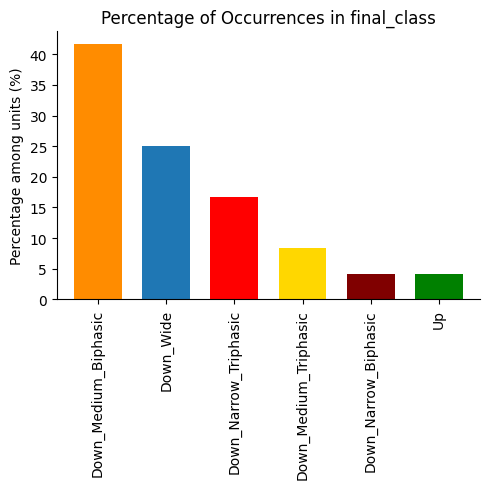

In [12]:
all_names = df_sua['final_class']
percentages = all_names.value_counts(normalize=True) * 100

plt.figure(figsize=(5, 5))
colors = [COLORS_CLASSES.get(name, 'gray') for name in percentages.index]
ax = percentages.plot(kind='bar',width=0.7,color=colors)
plt.ylabel('Percentage among units (%)')
plt.xlabel('')
plt.title('Percentage of Occurrences in final_class')

for pos in ['top','right']:
    ax.spines[pos].set_visible(False)

plt.tight_layout()
plt.show()

### Waveforms

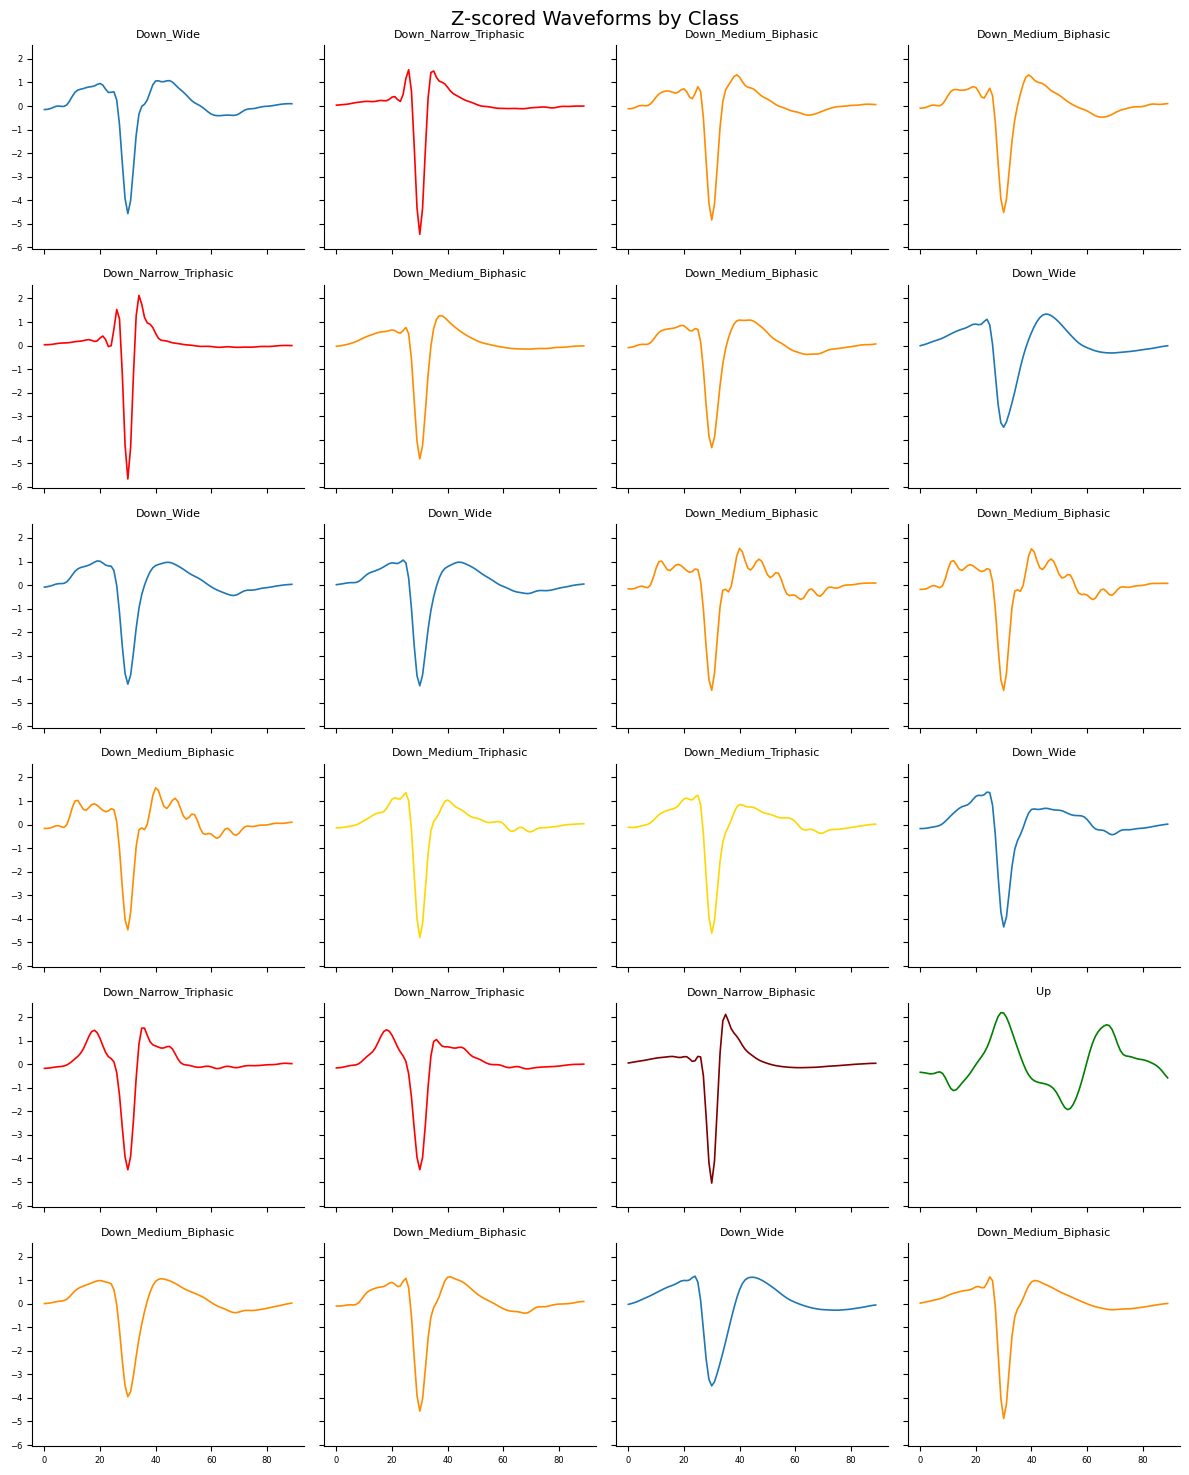

In [13]:
waveforms = df_sua['z_scored_waveform']
classes = df_sua['final_class']

n = len(df_sua)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 2.5), sharex=True, sharey=True)
axes = axes.flatten()

for i, (wf, cls) in enumerate(zip(waveforms, classes)):
    ax = axes[i]
    
    color = COLORS_CLASSES.get(cls, 'gray')
    ax.plot(wf, color=color, linewidth=1.2)
    
    ax.set_title(cls, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Z-scored Waveforms by Class', fontsize=14)
plt.tight_layout()
plt.show()


## Sandbox

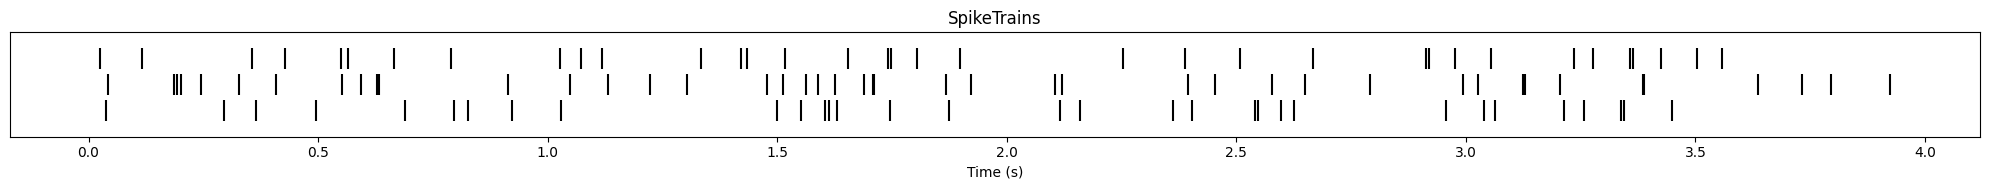

In [14]:
import matplotlib.pyplot as plt

st = block.segments[0].spiketrains[10]
st2 = block.segments[0].spiketrains[11]
st3 = block.segments[0].spiketrains[12]

STOP_T = 4
spikes = st[st < STOP_T].magnitude
spikes2 = st2[st2 < STOP_T].magnitude
spikes3 = st3[st3 < STOP_T].magnitude


plt.figure(figsize=(20, 2))
plt.eventplot([spikes,spikes2,spikes3], colors='black', lineoffsets=[1,2,3], linelengths=0.8)

plt.xlabel('Time (s)')
plt.yticks([])
plt.title('SpikeTrains')
plt.tight_layout()
plt.show()

